In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (데이터 시각화를 위해 필요)
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

강남 3구 보유 현황 요약:
강남3구보유
False    241
True      93
Name: count, dtype: int64


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31860\1397674533.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_val.index, y=district_val.values, palette='Reds_r', ax=ax[1])


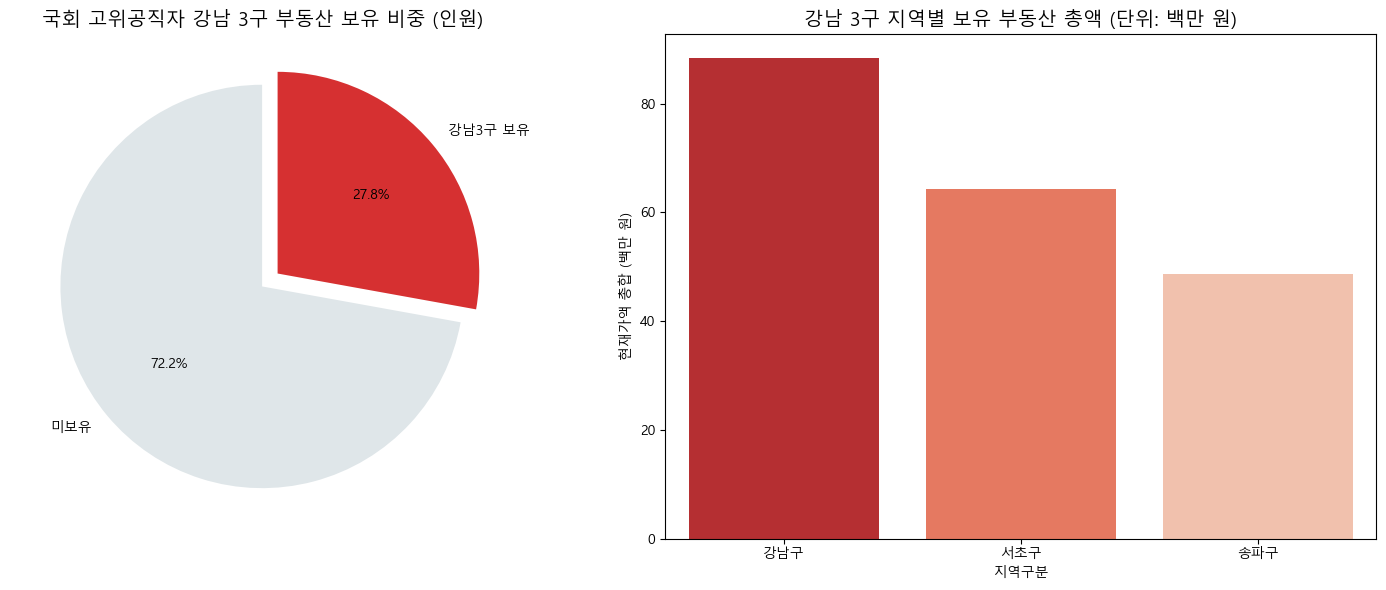


강남 3구 부동산 가액 상위 5인:
이름
박덕흠    28710503
김은혜    20087369
서명옥     9590000
이언주     4567162
최은석     4530000
Name: 현재가액_int, dtype: int64


In [2]:
# 데이터 재로드 및 전처리
file_path = '2025 국회고위공직자 재산정보_분석테스트용 - 상세.csv'
df = pd.read_csv(file_path)

def robust_clean(x):
    if isinstance(x, str):
        x = x.strip().replace(',', '')
        if x == '-' or x == '': return 0
        try: return int(x)
        except: return 0
    return x

df['현재가액_int'] = df['현재가액'].apply(robust_clean)

# 부동산(건물, 토지) 데이터만 필터링
real_estate_df = df[df['재산구분'].isin(['건물', '토지'])].copy()

# 강남 3구(강남, 서초, 송파) 판별
gangnam_3 = ['강남구', '서초구', '송파구']
def classify_location(addr):
    addr = str(addr)
    for dist in gangnam_3:
        if dist in addr:
            return dist
    if '서울특별시' in addr or '서울시' in addr:
        return '기타 서울'
    return '비서울/기타'

real_estate_df['지역구분'] = real_estate_df['소재지 면적 등 권리의 명세'].apply(classify_location)

# 1. 고위공직자 개인별 강남3구 보유 여부 분석
officials = real_estate_df.groupby('이름')['지역구분'].apply(list).reset_index()
officials['강남3구보유'] = officials['지역구분'].apply(lambda x: any(d in x for d in gangnam_3))

summary = officials['강남3구보유'].value_counts()
print("강남 3구 보유 현황 요약:")
print(summary)

# 2. 강남 3구 내 부동산 가액 비중 계산
gangnam_value = real_estate_df[real_estate_df['지역구분'].isin(gangnam_3)]['현재가액_int'].sum()
total_re_value = real_estate_df['현재가액_int'].sum()

# 시각화 데이터 생성
# (1) 강남 3구 보유 비중 (인원수 기준)
# (2) 강남 3구 부동산 가액 상세 (강남 vs 서초 vs 송파)

# 그래프 그리기
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 좌측: 인원 비중 (Pie Chart)
ax[0].pie(summary, labels=['미보유', '강남3구 보유'], autopct='%1.1f%%', startangle=90, colors=['#dfe6e9', '#d63031'], explode=[0, 0.1])
ax[0].set_title('국회 고위공직자 강남 3구 부동산 보유 비중 (인원)', fontsize=14)

# 우측: 강남 3구별 부동산 총액 (Bar Chart)
district_val = real_estate_df[real_estate_df['지역구분'].isin(gangnam_3)].groupby('지역구분')['현재가액_int'].sum() / 1000000 # 백만 단위
district_val = district_val.sort_values(ascending=False)
sns.barplot(x=district_val.index, y=district_val.values, palette='Reds_r', ax=ax[1])
ax[1].set_title('강남 3구 지역별 보유 부동산 총액 (단위: 백만 원)', fontsize=14)
ax[1].set_ylabel('현재가액 총합 (백만 원)')

plt.tight_layout()
plt.show()

# 추가 분석: 강남 3구 최다 보유자(가액 기준) 상위 5명
top_holders = real_estate_df[real_estate_df['지역구분'].isin(gangnam_3)].groupby('이름')['현재가액_int'].sum().sort_values(ascending=False).head(5)
print("\n강남 3구 부동산 가액 상위 5인:")
print(top_holders)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_31860\2535484109.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=location_value, x='지역구분', y='현재가액_int', palette='viridis')


전체 공직자 수: 335
강남 3구 부동산 보유 공직자 수: 93
비중: 27.76%

[지역별 가액 합계]
     지역구분   현재가액_int
2  비서울/기타  220441911
1   기타 서울  214861850
0     강남구   88359521
3     서초구   64346776
4     송파구   48750843


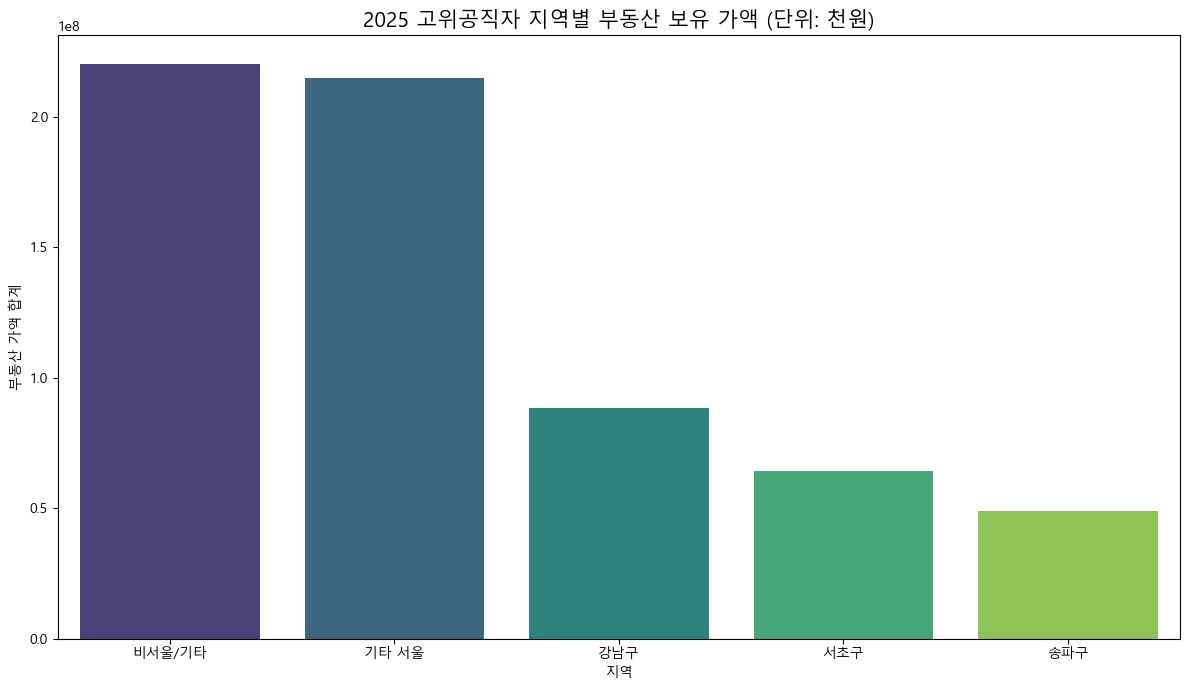

In [3]:
# 1. 지역별 부동산 가액 합계 분석
location_value = real_estate_df.groupby('지역구분')['현재가액_int'].sum().reset_index()
location_value = location_value.sort_values(by='현재가액_int', ascending=False)

# 2. 강남 3구 보유 공직자 수 분석
gangnam_owners = real_estate_df[real_estate_df['지역구분'].isin(['강남구', '서초구', '송파구'])]['이름'].unique()
total_officials = df['이름'].nunique()
gangnam_ratio = len(gangnam_owners) / total_officials * 100

# 시각화: 지역별 부동산 가액 분포
plt.figure(figsize=(12, 7))
sns.barplot(data=location_value, x='지역구분', y='현재가액_int', palette='viridis')
plt.title('2025 고위공직자 지역별 부동산 보유 가액 (단위: 천원)', fontsize=15)
plt.ylabel('부동산 가액 합계')
plt.xlabel('지역')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('real_estate_by_location.png')

# 결과 출력용 데이터
print(f"전체 공직자 수: {total_officials}")
print(f"강남 3구 부동산 보유 공직자 수: {len(gangnam_owners)}")
print(f"비중: {gangnam_ratio:.2f}%")
print("\n[지역별 가액 합계]")
print(location_value)

In [4]:
# Check for party information and categorize property types
print("Unique values in '소속':", df['소속'].unique())
print("Unique values in '직위':", df['직위'].unique()[:10])

# Property type categorization
def categorize_property(p_type):
    p_type = str(p_type)
    if '아파트' in p_type: return '아파트'
    elif '상가' in p_type or '오피스텔' in p_type or '사무실' in p_type or '근린생활시설' in p_type: return '상업용/오피스'
    elif '대지' in p_type or '임야' in p_type or '전' in p_type or '답' in p_type: return '토지'
    elif '단독주택' in p_type or '연립주택' in p_type or '다세대주택' in p_type: return '기타 주거용'
    else: return '기타'

gangnam_df = real_estate_df[real_estate_df['지역구분'].isin(['강남구', '서cho구', '송파구'])].copy() # Fixed typo in my logic
# Actually I need to re-run the filtering properly
gangnam_3_districts = ['강남구', '서초구', '송파구']
gangnam_3_owners_df = real_estate_df[real_estate_df['소재지 면적 등 권리의 명세'].str.contains('|'.join(gangnam_3_districts))].copy()

gangnam_3_owners_df['건물유형'] = gangnam_3_owners_df['재산의종류'].apply(categorize_property)

# Property type distribution for Gangnam-3 owners
prop_type_dist = gangnam_3_owners_df.groupby('건물유형')['현재가액_int'].sum().sort_values(ascending=False)
print("\n[강남 3구 보유 부동산 유형별 가액]")
print(prop_type_dist)

# Check if party info exists. Usually in these files, it might be in '소속' or not present.
# Based on common public data, it's often missing in the raw 'property' csv.
# Let's check if '소속' has party names like '국민의힘', '더불어민주당' etc.
has_party = df['소속'].str.contains('민주당|국민의힘|정의당|개혁신당').any()
print(f"Party info found: {has_party}")

Unique values in '소속': ['국회']
Unique values in '직위': ['국회의장' '국회부의장' '국회의원' '국회사무총장' '입법차장' '사무차장' '의장비서실장' '수석전문위원' '수석비서관'
 '정책연구위원']

[강남 3구 보유 부동산 유형별 가액]
건물유형
아파트        136779874
토지          24799611
기타          18792369
상업용/오피스     18530286
기타 주거용       2555000
Name: 현재가액_int, dtype: int64
Party info found: False


In [5]:
# Check unique values in columns that might contain party info
print("Columns:", df.columns)
print("Unique 소속:", df['소속'].unique())
print("Unique 구분:", df['구분'].unique())

# Property types in Gangnam-3
gangnam_3 = ['강남구', '서초구', '송파구']
def is_gangnam(addr):
    addr = str(addr)
    return any(g in addr for g in gangnam_3)

df_re = df[df['재산구분'].isin(['건물', '토지'])].copy()
df_re['is_gangnam'] = df_re['소재지 면적 등 권리의 명세'].apply(is_gangnam)

gangnam_owners_data = df_re[df_re['is_gangnam']]
print("\n[Gangnam-3 Property Types]")
print(gangnam_owners_data['재산의종류'].value_counts())

# Check names to see if party is mentioned in some rows or if it's missing
print("\nSample Rows:")
print(df[['이름', '소속', '직위']].drop_duplicates().head(10))

Columns: Index(['연월', 'NO', 'monaCode', '구분', '소속', '직위', '이름', '재산구분', '본인과의 관계',
       '재산의종류', '소재지 면적 등 권리의 명세', '종전가액', '증가액', '증가액실거래가격', '감소액',
       '감소액실거래가격', '현재가액', '변동사유', '현재가액_int'],
      dtype='object')
Unique 소속: ['국회']
Unique 구분: ['1.국회의원' '2.국회사무처' '3.국회도서관' '4.국회예산정책처' '5.국회입법조사처']

[Gangnam-3 Property Types]
재산의종류
아파트                101
아파트(전세(임차)권)        25
대지                  14
오피스텔                 6
사무실(전세(임차)권)         5
상가                   5
오피스텔(전세(임차)권)        5
근린생활시설               4
아파트(분양권)             3
다세대주택                3
아파트(전세(임 차)권)        3
근린생활시설(전세(임차)권)      2
복합건물(주택+상가)          2
빌딩                   1
다세대주택(전세(임차)권)       1
빌딩(전세(임차)권)          1
연립주택                 1
오피스텔(분양권)            1
Name: count, dtype: int64

Sample Rows:
      이름  소속     직위
0    우원식  국회   국회의장
17   이학영  국회  국회부의장
41   주호영  국회  국회부의장
62   강경숙  국회   국회의원
78   강대식  국회   국회의원
90   강득구  국회   국회의원
102  강명구  국회   국회의원
120  강민국  국회   국회의원
136  강선영  국회   국회의원
149  강

In [12]:
# Load the two files
df_detail = pd.read_csv('2025 국회고위공직자 재산정보_분석테스트용 - 상세.csv')
df_summary = pd.read_csv('2025 국회고위공직자 재산정보_분석테스트용 - 총계_명단.csv')

# Preprocessing: Clean numerical columns
def robust_clean(x):
    if isinstance(x, str):
        x = x.strip().replace(',', '')
        if x == '-' or x == '': return 0
        try: return int(x)
        except: return 0
    return x

df_detail['현재가액_int'] = df_detail['현재가액'].apply(robust_clean)

# Merge data
# Use monaCode if available, otherwise name. monaCode seems to be in both.
# Checking columns of summary
print("Summary columns:", df_summary.columns)
# Standardize name columns for merge if needed
# Summary uses '성명', Detail uses '이름'
df_merged = pd.merge(df_detail, df_summary[['monaCode', '성명', '정당(2026.02.26)']], left_on='monaCode', right_on='monaCode', how='left')

# 1. Top 10 Most Expensive Apartments
# Filtering for '아파트' (excluding lease/jeonse for 'pure' ownership ranking, but usually current value represents ownership)
# Let's check '재산의종류' values first
print(df_merged['재산의종류'].unique())

# Filter for real ownership of apartments (not rent/jeonse)
apt_df = df_merged[df_merged['재산의종류'] == '아파트'].copy()
top_10_apt = apt_df.sort_values(by='현재가액_int', ascending=False).head(10)

print("\n[Top 10 Most Expensive Apartments]")
print(top_10_apt[['이름', '정당(2026.02.26)', '소재지 면적 등 권리의 명세', '현재가액_int']])

# 2. Party based analysis
# Average Real Estate Value (Buildings + Land) per official in each party
re_df = df_merged[df_merged['재산구분'].isin(['건물', '토지'])].copy()
party_re_stats = re_df.groupby(['정당(2026.02.26)', '이름'])['현재가액_int'].sum().reset_index()
party_avg = party_re_stats.groupby('정당(2026.02.26)')['현재가액_int'].mean().sort_values(ascending=False)

print("\n[Average Real Estate Value by Party]")
print(party_avg)

# Gangnam 3 concentration by party
gangnam_3 = ['강남구', '서초구', '송파구']
re_df['is_gangnam'] = re_df['소재지 면적 등 권리의 명세'].apply(lambda x: any(g in str(x) for g in gangnam_3))
gangnam_by_party = re_df[re_df['is_gangnam']].groupby('정당(2026.02.26)')['이름'].nunique()
total_by_party = df_summary.groupby('정당(2026.02.26)')['성명'].nunique()
gangnam_ratio = (gangnam_by_party / total_by_party * 100).sort_values(ascending=False)

print("\n[Gangnam-3 Property Owner Ratio by Party]")
print(gangnam_ratio)

Summary columns: Index(['연월', 'No', 'monaCode', '구분', '소속', '직위', '성명', '정당(2026.02.26)',
       '재선횟수', '위원회(2026.02.26)', '종전가액', '증가액', '감소액', '현재가액', '증감액', '가액변동'],
      dtype='object')
['임야' '대지' '연립주택' '사무실(전세(임차)권)' '근린생활시설(전세(임차)권)' '상가' '자동차' nan '금융채무'
 '건물임대채무' '전' '답' '아파트' '근린생활시설' '아파트(전세(임차)권)' '단독주택' '사무실(전세(임 차)권)'
 '아파트(전세(임 차)권)' '복합건물(주택+상가)' '비상장주식' '상장주식' '국채' '회사채' '기타(채권)'
 '오피스텔(전세(임차)권)' '다세대주택(전세(임차)권)' '도로' '상가(전세(임차)권)' '잡종지' '창고' '토지임대채무'
 '헬스' '출자' '단독주택(전세(임차)권)' '다가구주택' '오피스텔' '숙박시설(전세(임차)권)' '콘도미니엄' '기타'
 '복합건물(주택+ 상가)(전세(임차)권)' '묘지' '오피스텔(전세( 임차)권)' '목장용지' '다세대주택' '금융채'
 '빌딩(전세(임차)권)' '저작재산권' '아파트(분양권)' '근린생활시설( 전세(임차)권)' '빌딩' '다가구주택(전세(임차)권)'
 '하천' '단독주택(전세( 임차)권)' '출연' '사무실' '과수원' '골프' '공원' '동·식물 관련시설'
 '숙박시설(전세( 임차)권)' '주차장' '공장' '연립주택(전세(임차)권)' '복합건물(주택+상가)(전세(임 차)권)'
 '숙박시설' '교육연구 및 복지시설(전세(임차)권)' '유원지' '다가구주택(전 세(임차)권)' '창고용지' '선박'
 '기타(전세(임차)권)' '동·식물 관련 시설' '지방채' '공장용지' '교육연구 및복지시설' '복합건물(주택+ 상가)' '공채'
 '오피스텔(분양권)']

[Top 10 Most Expensive A

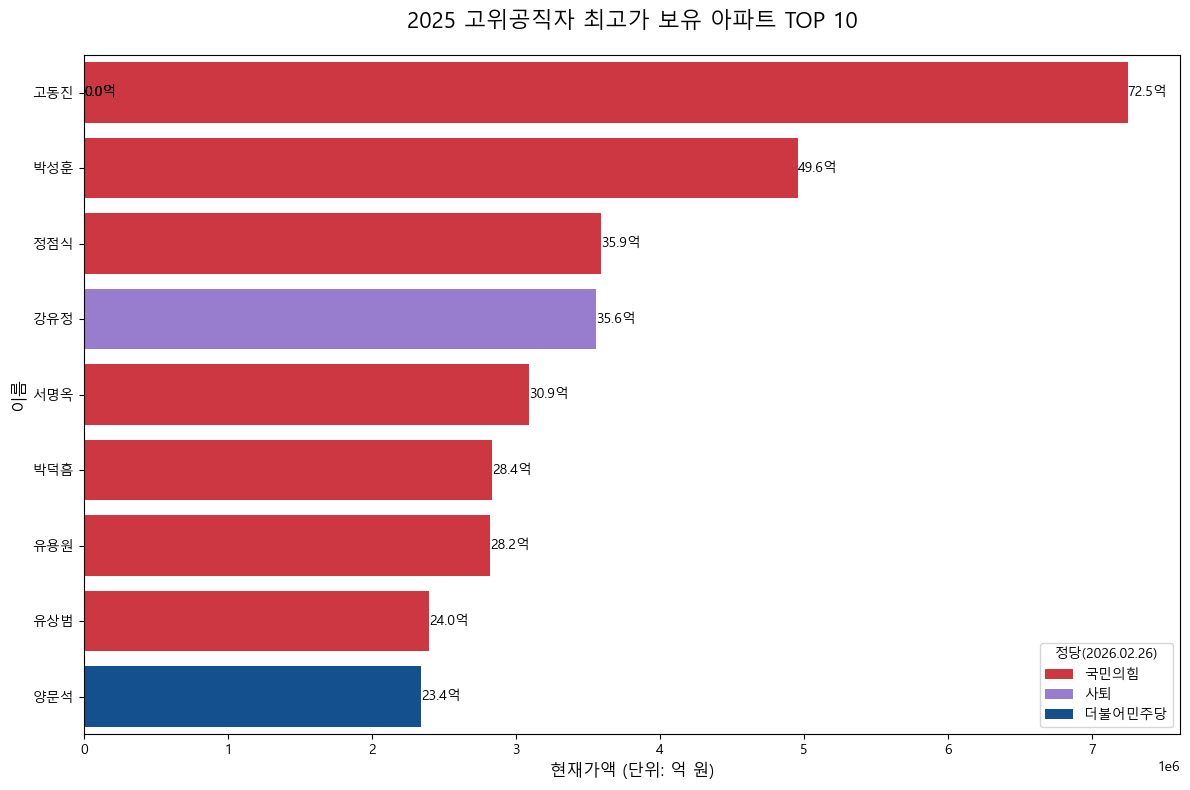

In [10]:
# 정당별 상징색 설정
party_colors = {
    '국민의힘': '#E61E2B',
    '더불어민주당': '#004EA2',
    '조국혁신당': '#003580',
    '개혁신당': '#FF6600',
    '무소속': '#808080',
    '사퇴':  '#9370DB'
}

# 1. Top 10 아파트 시각화
plt.figure(figsize=(12, 8))
top_10_plot = sns.barplot(
    data=top_10_apt, 
    x='현재가액_int', 
    y='이름', 
    hue='정당(2026.02.26)', 
    palette=party_colors,
    dodge=False
)

plt.title('2025 고위공직자 최고가 보유 아파트 TOP 10', fontsize=16, pad=20)
plt.xlabel('현재가액 (단위: 억 원)', fontsize=12)
plt.ylabel('이름', fontsize=12)

# 가액 라벨링 (억 단위로 표시)
for p in top_10_plot.patches:
    val = p.get_width()
    plt.text(val, p.get_y() + p.get_height()/2, f'{val/100000:,.1f}억', va='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33712\3084899064.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


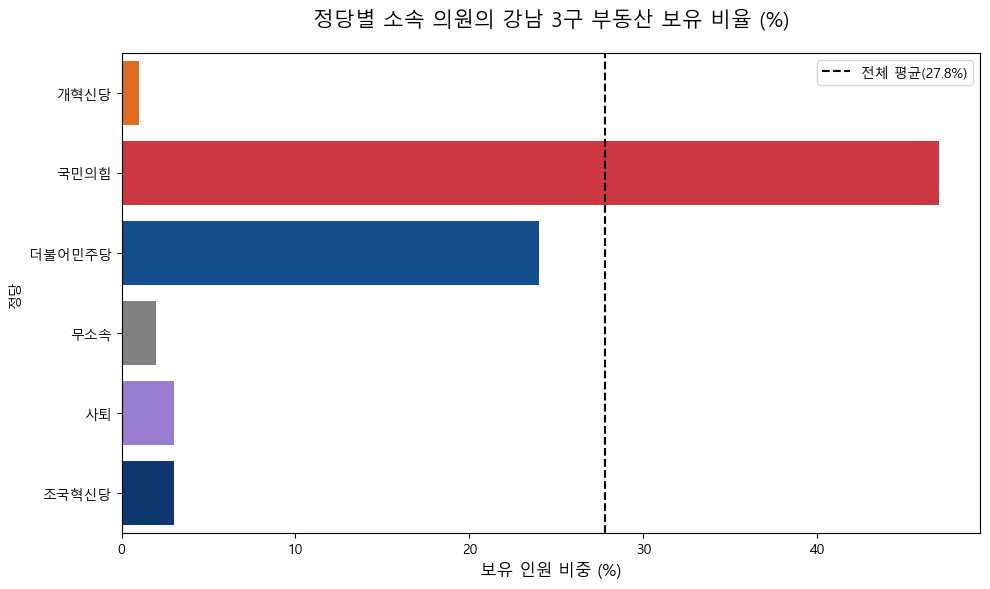

In [14]:
# 2. 정당별 강남 3구 보유 비중 차트
plt.figure(figsize=(10, 6))
gangnam_ratio_df = gangnam_by_party.reset_index()
gangnam_ratio_df.columns = ['정당', '보유비중']

sns.barplot(
    data=gangnam_ratio_df, 
    x='보유비중', 
    y='정당', 
    palette=party_colors
)

plt.title('정당별 소속 의원의 강남 3구 부동산 보유 비율 (%)', fontsize=15, pad=20)
plt.xlabel('보유 인원 비중 (%)', fontsize=12)
plt.axvline(x=27.8, color='black', linestyle='--', label='전체 평균(27.8%)') # 전체 평균선
plt.legend()
plt.tight_layout()
plt.show()

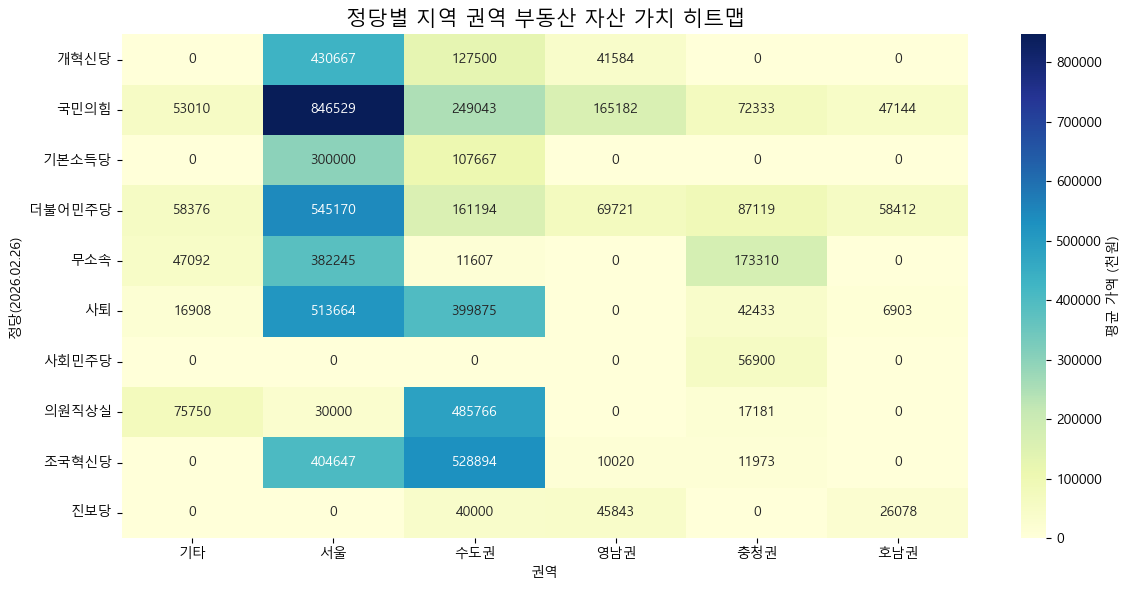

In [16]:
# 지역 대분류 생성
def get_region(addr):
    addr = str(addr)
    if '서울' in addr: return '서울'
    elif '경기' in addr or '인천' in addr: return '수도권'
    elif '경상' in addr or '대구' in addr or '부산' in addr or '울산' in addr: return '영남권'
    elif '전라' in addr or '광주' in addr: return '호남권'
    elif '충청' in addr or '대전' in addr or '세종' in addr: return '충청권'
    else: return '기타'

re_df['권역'] = re_df['소재지 면적 등 권리의 명세'].apply(get_region)

# 정당별 권역별 자산 가치 평균 피벗 테이블
heatmap_data = re_df.groupby(['정당(2026.02.26)', '권역'])['현재가액_int'].mean().unstack().fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': '평균 가액 (천원)'})
plt.title('정당별 지역 권역 부동산 자산 가치 히트맵', fontsize=15)
plt.tight_layout()
plt.show()

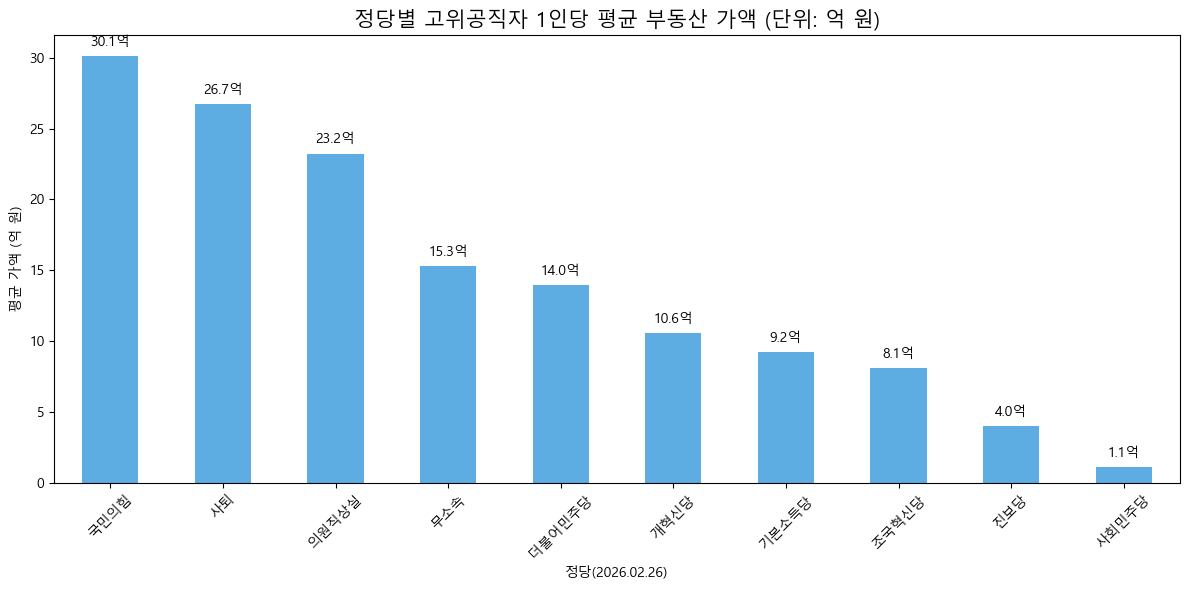

In [21]:
# 1. 정당별 인원수 계산
party_counts = re_df.groupby('정당(2026.02.26)')['이름'].nunique()

# 2. 1인당 부동산 가액 및 보유수 계산
party_re_val = re_df.groupby('정당(2026.02.26)')['현재가액_int'].sum()
party_re_count = re_df.groupby('정당(2026.02.26)')['현재가액_int'].count()

per_person_val = (party_re_val / party_counts).sort_values(ascending=False)
per_person_count = (party_re_count / party_counts).sort_values(ascending=False)

# 시각화: 1인당 평균 부동산 가액 (단위: 억 원)
plt.figure(figsize=(12, 6))
per_person_val_plot = (per_person_val / 100000).plot(kind='bar', color='#5DADE2')
plt.title('정당별 고위공직자 1인당 평균 부동산 가액 (단위: 억 원)', fontsize=15)
plt.ylabel('평균 가액 (억 원)')
plt.xticks(rotation=45)

# 상단에 수치 표시
for p in per_person_val_plot.patches:
    per_person_val_plot.annotate(f'{p.get_height():.1f}억', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33712\3628336656.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='정당', y='보유수', ax=ax1, palette='viridis', alpha=0.7)


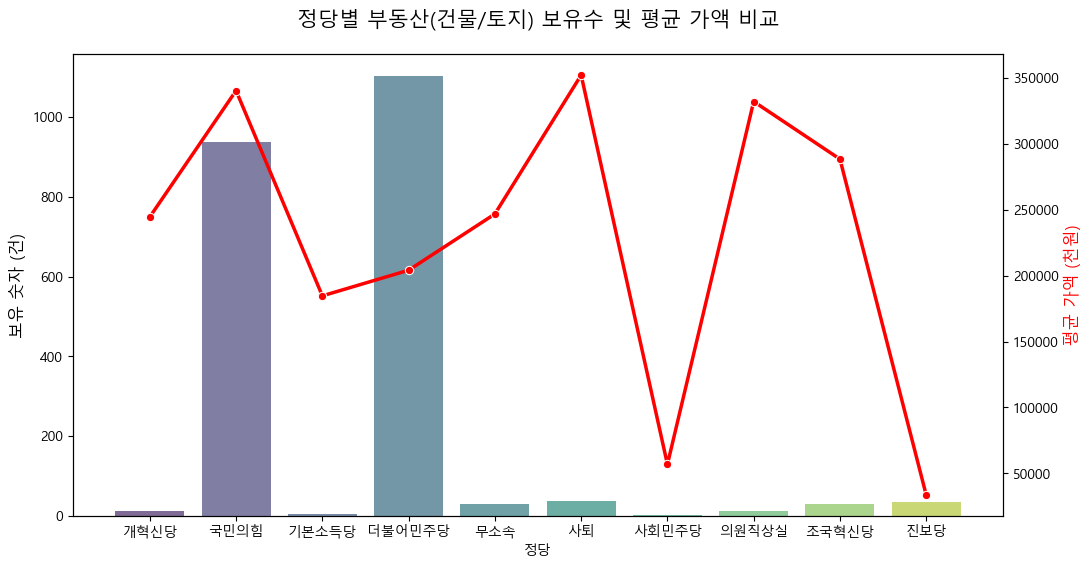

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33712\3628336656.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='정당', y='보유수', ax=ax1, palette='viridis', alpha=0.7)


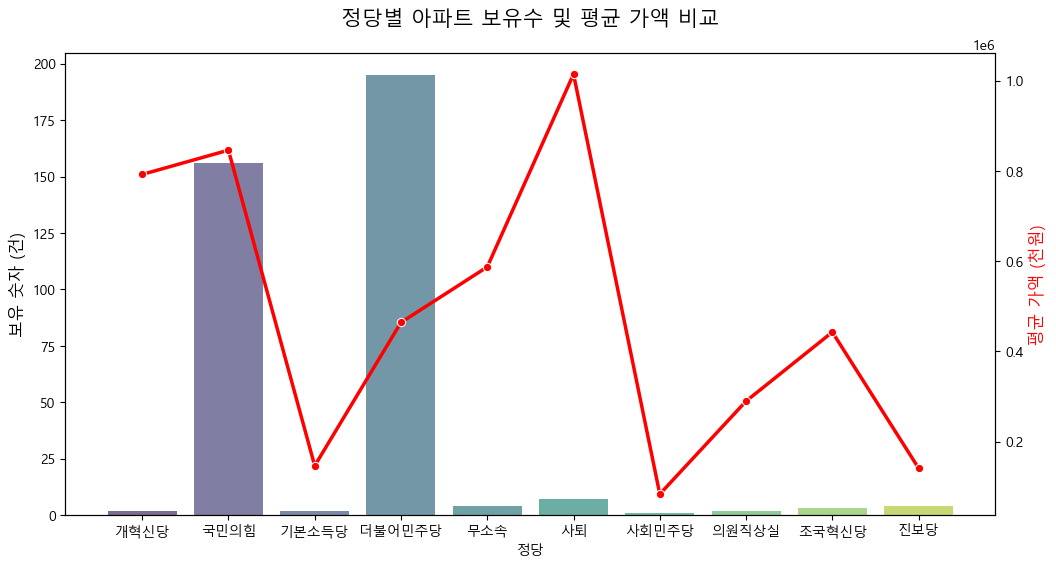

In [18]:
# 데이터 집계 (merged_df 기준)
# 1) 전체 부동산(건물+토지) 집계
re_stats = re_df.groupby('정당(2026.02.26)').agg({'현재가액_int': ['count', 'mean']}).reset_index()
re_stats.columns = ['정당', '보유수', '평균가액']

# 2) 아파트만 집계
apt_stats = apt_df.groupby('정당(2026.02.26)').agg({'현재가액_int': ['count', 'mean']}).reset_index()
apt_stats.columns = ['정당', '보유수', '평균가액']

# 시각화 함수
def draw_party_comparison(data, title):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # 보유수 (막대 그래프)
    sns.barplot(data=data, x='정당', y='보유수', ax=ax1, palette='viridis', alpha=0.7)
    ax1.set_ylabel('보유 숫자 (건)', fontsize=12)
    
    # 평균 가액 (선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(data=data, x='정당', y='평균가액', ax=ax2, color='red', marker='o', linewidth=2.5)
    ax2.set_ylabel('평균 가액 (천원)', fontsize=12, color='red')
    
    plt.title(title, fontsize=15, pad=20)
    plt.show()

# 실행
draw_party_comparison(re_stats, '정당별 부동산(건물/토지) 보유수 및 평균 가액 비교')
draw_party_comparison(apt_stats, '정당별 아파트 보유수 및 평균 가액 비교')